In [7]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../Excercises/08-Linear-Regression-Models/Advertising.csv')

In [9]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
df['total_spend'] = df['TV'] + df['radio'] + df['newspaper'] + df['sales']

In [11]:
df.head()

,TV,radio,newspaper,sales,total_spend
0,230.1,37.8,69.2,22.1,359.2
1,44.5,39.3,45.1,10.4,139.3
2,17.2,45.9,69.3,9.3,141.7
3,151.5,41.3,58.5,18.5,269.8
4,180.8,10.8,58.4,12.9,262.9


<Axes: xlabel='total_spend', ylabel='sales'>

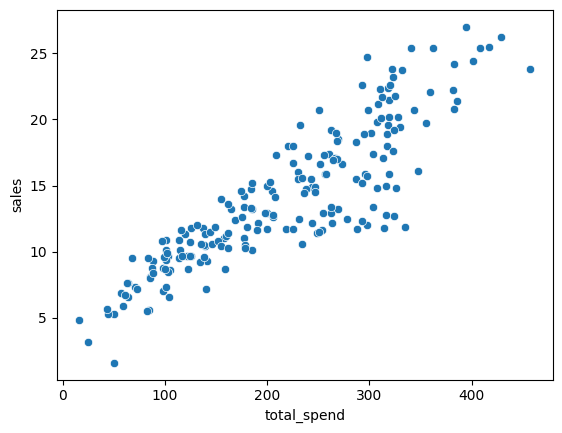

In [12]:
sns.scatterplot(data=df,x='total_spend',y='sales')

<Axes: xlabel='total_spend', ylabel='sales'>

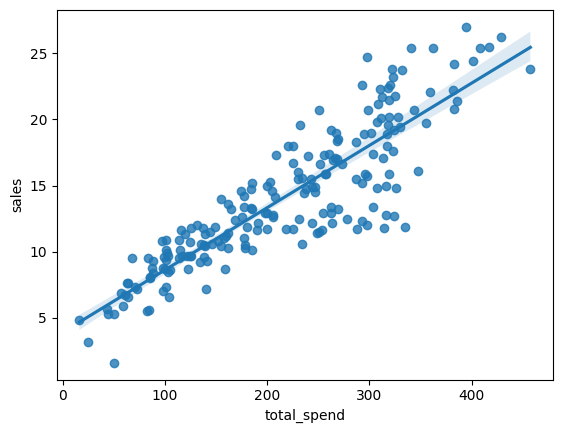

In [13]:
sns.regplot(data=df,x='total_spend',y='sales')

In [14]:
x = df['total_spend']
y = df['sales']

In [15]:
slope,intercept = np.polyfit(x,y,deg=1)

In [16]:
potential_spend = np.linspace(0,500,100)

In [17]:
predicted_sales = intercept + potential_spend*slope

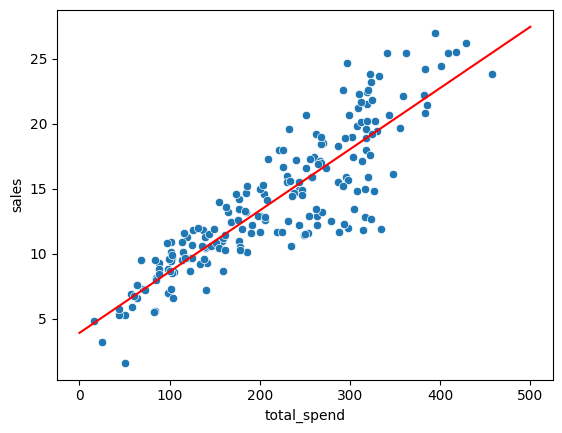

In [18]:
sns.scatterplot(data=df,x='total_spend',y='sales')
plt.plot(potential_spend,predicted_sales,color='red')

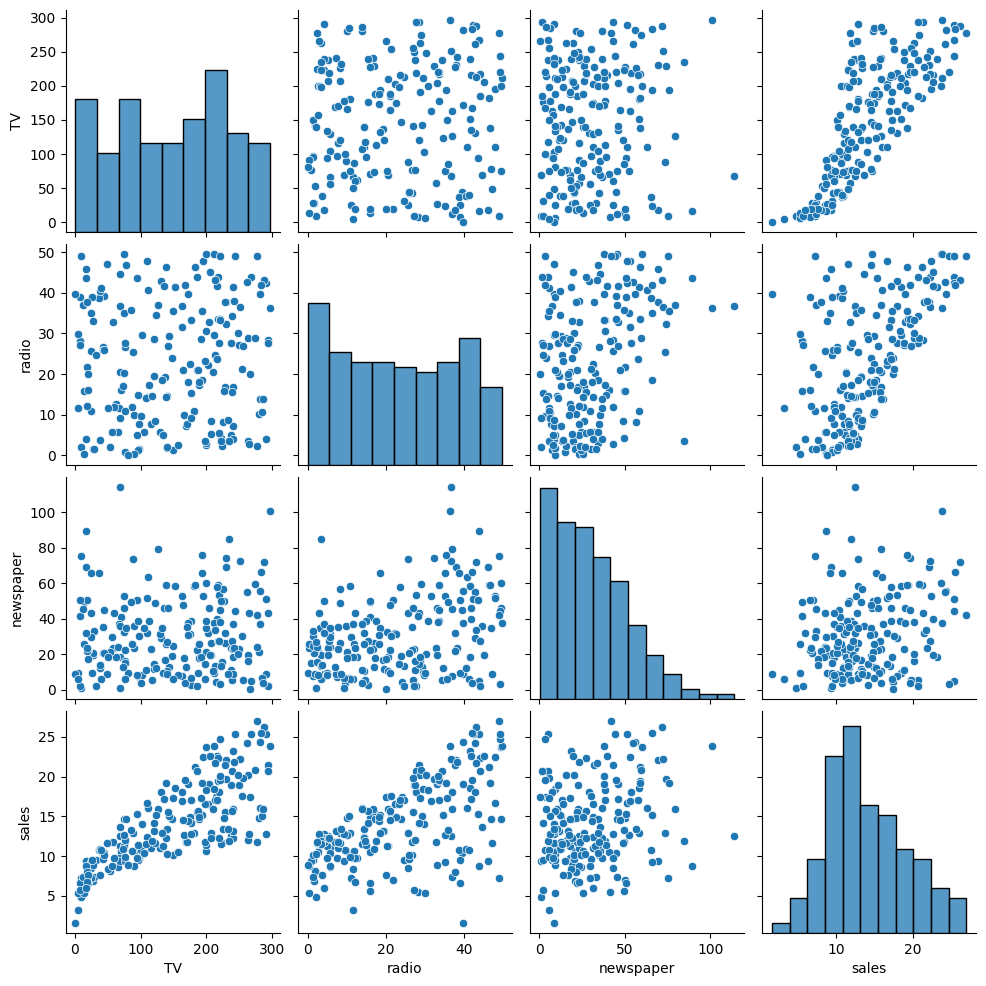

In [19]:
sns.pairplot(data=df[['TV', 'radio', 'newspaper', 'sales']])

<Axes: >

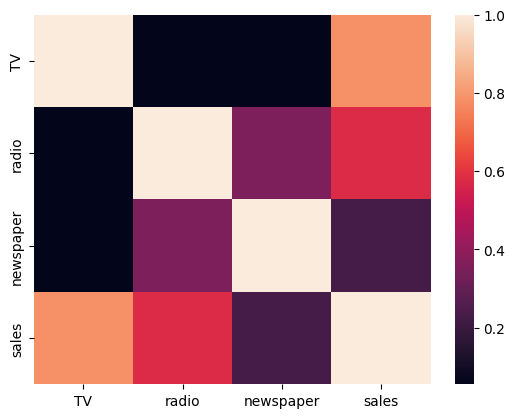

In [20]:
mat = df[['TV', 'radio', 'newspaper', 'sales']].corr()
sns.heatmap(mat)

In [21]:
x = df.drop(['total_spend','sales'],axis=1)
y = df['sales']

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=47)

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
predictions = model.predict(X_test)

In [62]:
predictions

array([-1.60499996e+01, -1.02403893e-01,  3.87187457e+01,  9.41991461e+00,
        7.29997322e+00,  8.96750730e+00,  1.05482552e+01, -9.20544627e+01,
        8.59930608e+00,  6.20212849e+01,  1.68697121e+01,  1.51071792e+01,
        1.57617651e+01,  8.04055151e+00, -9.21080276e+04,  1.08717432e+01,
        9.39208174e+00,  2.05907672e+01,  1.96423691e+01,  1.32152444e+01,
        1.76154116e+01,  8.15063918e+01,  1.13294808e+01,  1.74458937e+01,
        7.08637412e+00,  1.22057135e+01,  1.15714960e+01,  1.57930784e+01,
        1.87460065e+01,  8.70955456e+00,  2.20654791e+01,  9.62072369e+00,
        1.51967555e+01,  2.17204086e+01,  9.43841150e+00,  1.30426776e+01,
        1.64836712e+01,  1.50077067e+01,  8.37727672e+00,  2.38266459e+01])

In [63]:
y_train.mean(),y_train.median()

(np.float64(14.295000000000002), np.float64(13.25))

In [64]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
print(mae)

2312.3398531571


In [65]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
print(mse)

212155336.08108398


In [66]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,predictions)
print(rmse)

14565.553064716903


In [67]:
# Percentage of error interms of mean will be 12% more than average so on an average it will be off by 12%
(1.7/14)*100

12.142857142857142

In [68]:
residuals = y_test - predictions

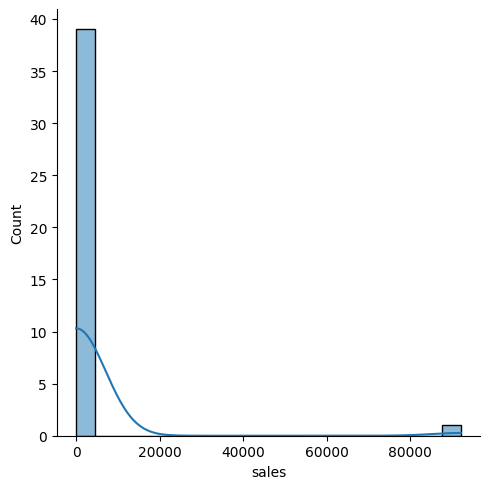

In [69]:
sns.displot(residuals,bins=20,kde=True)

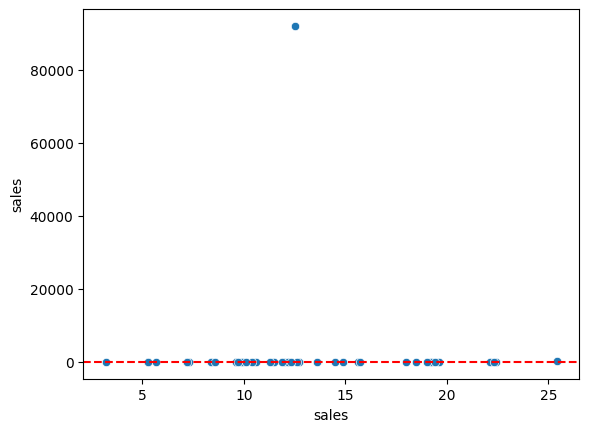

In [70]:
sns.scatterplot(x=y_test,y=residuals)
plt.axhline(y=0,color='red',ls='--')

In [71]:
# Polynomial regression

In [72]:
X = df.drop(columns = ['sales','total_spend'])
Y = df['sales']

In [73]:
X,Y

(            TV     radio  newspaper
 0   230.100000 37.800000  69.200000
 1    44.500000 39.300000  45.100000
 2    17.200000 45.900000  69.300000
 3   151.500000 41.300000  58.500000
 4   180.800000 10.800000  58.400000
 ..         ...       ...        ...
 195  38.200000  3.700000  13.800000
 196  94.200000  4.900000   8.100000
 197 177.000000  9.300000   6.400000
 198 283.600000 42.000000  66.200000
 199 232.100000  8.600000   8.700000
 
 [200 rows x 3 columns],
 0     22.100000
 1     10.400000
 2      9.300000
 3     18.500000
 4     12.900000
          ...   
 195    7.600000
 196    9.700000
 197   12.800000
 198   25.500000
 199   13.400000
 Name: sales, Length: 200, dtype: float64)

In [74]:
from sklearn.preprocessing import PolynomialFeatures

In [75]:
polynomial_convertor = PolynomialFeatures(degree=2,include_bias = False)

In [76]:
polynomial_convertor.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [77]:
poly_features = polynomial_convertor.transform(X)

In [78]:
X

,TV,radio,newspaper
0,230.100000,37.800000,69.200000
1,44.500000,39.300000,45.100000
2,17.200000,45.900000,69.300000
3,151.500000,41.300000,58.500000
4,180.800000,10.800000,58.400000
...,...,...,...
195,38.200000,3.700000,13.800000
196,94.200000,4.900000,8.100000
197,177.000000,9.300000,6.400000
198,283.600000,42.000000,66.200000


In [79]:
X.iloc[0]

TV          230.100000
radio        37.800000
newspaper    69.200000
Name: 0, dtype: float64

In [80]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [81]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(poly_features,Y,test_size=0.2,random_state=47)

In [82]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
predictions = model.predict(X_test)

In [84]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
print('mae ',mae)
mse = mean_squared_error(y_test,predictions)
print('mse ',mse)
rmse = root_mean_squared_error(y_test,predictions)
print('rmse ',rmse)

mae  0.5010428495859747
mse  0.4801785127157977
rmse  0.6929491415073675


In [85]:
print((0.6929491415073723/14)*100)

4.94963672505266


In [86]:
def metrics(actual,predictions):
    mae = mean_absolute_error(actual,predictions)
    print('mae ',mae)
    mse = mean_squared_error(actual,predictions)
    print('mse ',mse)
    rmse = root_mean_squared_error(actual,predictions)
    print('rmse ',rmse)
    return mae,mse,rmse

In [87]:
metrics_dict = {
    'degree': [],
    'mae_train': [],
    'mse_train': [],
    'rmse_train': [],
    'mae_test': [],
    'mse_test': [],
    'rmse_test': [],
}
for d in range(1,10):
    print(f'Degree - {d}')
    polynomial_convertor = PolynomialFeatures(degree=d,include_bias = False)
    polynomial_convertor.fit(X)
    poly_features = polynomial_convertor.transform(X)
    X_train,X_test,y_train,y_test = train_test_split(poly_features,Y,test_size=0.2,random_state=47)
    model = LinearRegression()
    model.fit(X_train,y_train)
    print('Train Metrics')
    mae,mse,rmse = metrics(y_train,model.predict(X_train))
    metrics_dict['degree'].append(d)
    metrics_dict['mae_train'].append(mae)
    metrics_dict['mse_train'].append(mse)
    metrics_dict['rmse_train'].append(rmse)
    
    predictions = model.predict(X_test)
    print('Test Metrics')
    mae,mse,rmse = metrics(y_test,predictions)
    metrics_dict['mae_test'].append(mae)
    metrics_dict['mse_test'].append(mse)
    metrics_dict['rmse_test'].append(rmse)

Degree - 1
Train Metrics
mae  1.2096802024371083
mse  2.680672407511139
rmse  1.6372759106244552
Test Metrics
mae  1.3836057179961654
mse  3.2099110389833676
rmse  1.7916224599461148
Degree - 2
Train Metrics
mae  0.3926007631994981
mse  0.3494990921076374
rmse  0.5911844822960405
Test Metrics
mae  0.5010428495859747
mse  0.4801785127157977
rmse  0.6929491415073675
Degree - 3
Train Metrics
mae  0.3068913655778247
mse  0.21529653090913453
rmse  0.4640005721000078
Test Metrics
mae  0.36009062496767397
mse  0.26370344608080637
rmse  0.5135206384175872
Degree - 4
Train Metrics
mae  0.2696156283411394
mse  0.13501349222898495
rmse  0.36744182155680777
Test Metrics
mae  0.43920147520804054
mse  0.40375991042701437
rmse  0.6354210497198014
Degree - 5
Train Metrics
mae  0.18120449988641663
mse  0.05879317086113285
rmse  0.24247303120374614
Test Metrics
mae  0.8106425719385065
mse  7.853546649445745
rmse  2.8024180004856065
Degree - 6
Train Metrics
mae  0.16793468727386787
mse  0.048160777434375

In [88]:
df_metrics = pd.DataFrame(data=metrics_dict)

In [89]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [90]:
for col in df_metrics.columns:
    if df_metrics[col].dtype == float:
        df_metrics[col] = df_metrics[col].round(2)

In [91]:
cols = list(df_metrics.columns)
cols.sort()
df_metrics[cols]

,degree,mae_test,mae_train,mse_test,mse_train,rmse_test,rmse_train
0,1,1.380000,1.210000,3.210000,2.680000,1.790000,1.640000
1,2,0.500000,0.390000,0.480000,0.350000,0.690000,0.590000
2,3,0.360000,0.310000,0.260000,0.220000,0.510000,0.460000
3,4,0.440000,0.270000,0.400000,0.140000,0.640000,0.370000
4,5,0.810000,0.180000,7.850000,0.060000,2.800000,0.240000
5,6,4.460000,0.170000,603.210000,0.050000,24.560000,0.220000
6,7,2.260000,0.160000,79.890000,0.050000,8.940000,0.230000
7,8,65.740000,0.170000,152985.660000,0.090000,391.130000,0.310000
8,9,2312.340000,0.270000,212155336.080000,0.260000,14565.550000,0.510000


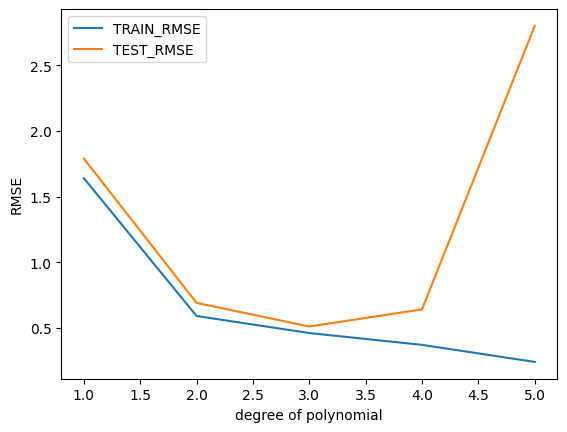

In [92]:
plt.plot(range(1,6),df_metrics['rmse_train'][:5],label='TRAIN_RMSE')
plt.plot(range(1,6),df_metrics['rmse_test'][:5],label='TEST_RMSE')
plt.xlabel('degree of polynomial')
plt.ylabel('RMSE')
plt.legend()

In [93]:
# Regularization

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [95]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [96]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [97]:
scaled_X_train

array([[-0.09504644,  0.39284758, -0.79770594, ..., -0.18682689,
        -0.16190745, -0.15450494],
       [-1.55029167, -0.78240684, -0.28999476, ..., -0.18678792,
        -0.16187617, -0.15448222],
       [-1.5678671 , -1.3290368 ,  0.09548966, ..., -0.18679044,
        -0.16178872, -0.1541643 ],
       ...,
       [-0.48287749, -0.6320836 ,  0.10019069, ..., -0.18633634,
        -0.16148134, -0.15415447],
       [-1.33704318,  1.02830491,  1.69383969, ...,  0.39792153,
         0.22542861,  0.08947976],
       [-1.20346994,  1.60226637, -0.99044815, ..., -0.18682961,
        -0.16190796, -0.15450503]], shape=(160, 219))

In [99]:
scaled_X_test

array([[-1.66746118,  1.73209099,  2.13573646, ...,  2.2093339 ,
         1.27050909,  0.65978585],
       [-1.43429386, -1.50669154,  0.16130407, ..., -0.18682294,
        -0.16184627, -0.1540017 ],
       [ 0.92667164,  0.97364192,  1.86307675, ...,  0.62824237,
         0.41967417,  0.24011856],
       ...,
       [ 1.04032605, -1.3290368 ,  0.34464423, ..., -0.18671259,
        -0.16149565, -0.15312952],
       [-1.72135915, -0.81657121, -1.12207698, ..., -0.18683014,
        -0.161908  , -0.15450503],
       [ 0.78138145,  0.67982831,  1.38357174, ...,  0.02283377,
        -0.01798459, -0.06055514]], shape=(40, 219))

In [100]:
from sklearn.linear_model import Ridge

In [102]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train,y_train)

C:\Users\nithishkumar\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [106]:
test_predictions = ridge_model.predict(X_test)

In [108]:
metrics(y_test,test_predictions)

mae  2.6124386904667136
mse  19.938739604201714
rmse  4.465281581737227


(2.6124386904667136, 19.938739604201714, 4.465281581737227)

In [109]:
from sklearn.linear_model import RidgeCV

In [110]:
ridge_cv_model = RidgeCV(alphas=(0.1,1,10))

In [112]:
ridge_cv_model.fit(X_train,y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [113]:
ridge_cv_model.alpha_

0.1

In [118]:
from sklearn.metrics import get_scorer_names

In [121]:
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [123]:
predictions = ridge_cv_model.predict(X_test)

In [124]:
metrics(y_test,predictions)

mae  69.50895709417998
mse  103231.85234425882
rmse  321.2971402677883


(69.50895709417998, 103231.85234425882, 321.2971402677883)